# Trabajo 2: Datos Base — Sistema de Recomendación por Géneros

**Asignatura**: Sistemas Recomendadores — MIARFID  
**Objetivo**: Construir un vector de preferencias de género por usuario a partir del dataset MovieLens.

Cada usuario tendrá un vector de 20 posiciones (una por género) con un ratio de preferencia normalizado.  
A la hora de recomendar, se filtrarán las **n posiciones más altas** del vector.

---

## 0. Instalación de dependencias e imports

Ejecuta esta celda para instalar las librerías necesarias (solo la primera vez).

In [10]:
# Instalar dependencias si no están disponibles
import subprocess, sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]: # <-- Aquí
    try:
        __import__(pkg)
    except ImportError:
        print(f"Instalando {pkg}...")
        install(pkg)

print("✅ Todas las dependencias están instaladas.")


Instalando scikit-learn...
✅ Todas las dependencias están instaladas.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

# Ruta base del dataset
DATA_DIR = Path('Data_set')

print(f"📁 Directorio de datos: {DATA_DIR.resolve()}")
print(f"📦 Archivos disponibles: {[f.name for f in DATA_DIR.iterdir() if f.is_file()]}")

📁 Directorio de datos: C:\Users\jlina\Desktop\Master\SR\Trabajo\SistemasRecomendadores-MIARFID\Trabajo\Data_set
📦 Archivos disponibles: ['generos.csv', 'keywords.csv', 'links.csv', 'peliculas.csv', 'ratings.csv', 'ratings_small.csv']


---
## Fase 1: Carga y Limpieza de Datos

### 1.1 Carga de los ficheros CSV

In [12]:
# --- Géneros ---
df_generos = pd.read_csv(DATA_DIR / 'generos.csv', sep=';', encoding='utf-8-sig')
print(f"🎭 Géneros cargados: {len(df_generos)}")
df_generos

🎭 Géneros cargados: 20


,id,IdDataset,Genero,GeneroSP
0,0,12,Adventure,Aventura
1,1,14,Fantasy,Fantas¡a
2,2,16,Animation,Animaci¢n
3,3,18,Drama,Drama
4,4,27,Horror,Terror
5,5,28,Action,Acción
6,6,35,Comedy,Comedia
7,7,36,History,Historica
8,8,37,Western,Oeste
9,9,53,Thriller,Suspense


In [13]:
# --- Películas ---
df_peliculas = pd.read_csv(DATA_DIR / 'peliculas.csv', sep=';', encoding='utf-8-sig', decimal=',')
print(f"🎬 Películas cargadas: {len(df_peliculas)}")
print(f"   Columnas: {list(df_peliculas.columns)}")
df_peliculas.head()

🎬 Películas cargadas: 27840
   Columnas: ['id', 'imdb_id', 'titulo', 'poster_path', 'puntuacion_media', 'votos', 'contgeneros', 'id_genero', 'id_genero.1', 'id_genero.2', 'id_genero.3', 'id_genero.4', 'id_genero.5', 'id_genero.6', 'id_genero.7']


,id,imdb_id,titulo,poster_path,puntuacion_media,votos,contgeneros,id_genero,id_genero.1,id_genero.2,id_genero.3,id_genero.4,id_genero.5,id_genero.6,id_genero.7
0,5,tt0113101,Four Rooms,/eQs5hh9rxrk1m4xHsIz1w11Ngqb.jpg,6.5,539,2,80,35.0,NaN,NaN,NaN,NaN,NaN,NaN
1,11,tt0076759,Star Wars,/btTdmkgIvOi0FFip1sPuZI2oQG6.jpg,8.1,6778,3,12,28.0,878.0,NaN,NaN,NaN,NaN,NaN
2,12,tt0266543,Finding Nemo,/syPWyeeqzTQIxjIUaIFI7d0TyEY.jpg,7.6,6292,2,16,10751.0,NaN,NaN,NaN,NaN,NaN,NaN
3,13,tt0109830,Forrest Gump,/yE5d3BUhE8hCnkMUJOo1QDoOGNz.jpg,8.2,8147,3,35,18.0,10749.0,NaN,NaN,NaN,NaN,NaN
4,14,tt0169547,American Beauty,/or1MP8BZIAjqWYxPdPX724ydKar.jpg,7.9,3438,1,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# --- Ratings ---
df_ratings = pd.read_csv(DATA_DIR / 'ratings_small.csv', sep=';', decimal=',')
print(f"⭐ Ratings cargados: {len(df_ratings)}")
print(f"   Usuarios únicos: {df_ratings['userId'].nunique()}")
print(f"   Películas únicas: {df_ratings['movieId'].nunique()}")
df_ratings.head()

⭐ Ratings cargados: 100004
   Usuarios únicos: 671
   Películas únicas: 9066


,userId,movieId,rating
0,1,31,2.5
1,1,1029,3.0
2,1,1061,3.0
3,1,1129,2.0
4,1,1172,4.0


In [15]:
# --- Keywords ---
df_keywords = pd.read_csv(DATA_DIR / 'keywords.csv', sep=';', encoding='utf-8-sig')
print(f"🔑 Keywords cargadas: {len(df_keywords)} películas")
df_keywords.head(3)

🔑 Keywords cargadas: 31622 películas


,id,contador,keyword,keyword.1,keyword.2,keyword.3,keyword.4,keyword.5,keyword.6,keyword.7,...,Unnamed: 235,Unnamed: 236,Unnamed: 237,Unnamed: 238,Unnamed: 239,Unnamed: 240,Unnamed: 241,Unnamed: 242,Unnamed: 243,Unnamed: 244
0,2,7,underdog,prison,factory worker,prisoner,helsinki,independent film,falling in love,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,4,salesclerk,helsinki,garbage,independent film,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,9,hotel,witch,bet,hotel room,sperm,los angeles,hoodlum,woman director,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# --- Links ---
df_links = pd.read_csv(DATA_DIR / 'links.csv', sep=';')
print(f"🔗 Links cargados: {len(df_links)} películas")
df_links.head(3)

🔗 Links cargados: 45843 películas


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


### 1.2 Mapeo Película → Géneros

El archivo `peliculas.csv` tiene las columnas de géneros como `id_genero` repetidas. Necesitamos extraer los IDs de género por cada película.

In [17]:
# Las columnas de género son todas las llamadas 'id_genero' (repetidas)
# Extraemos los IDs de género para cada película
genero_cols = [col for col in df_peliculas.columns if col.startswith('id_genero')]
print(f"Columnas de género encontradas: {genero_cols}")

# Crear un diccionario: id_pelicula -> lista de ids de género
pelicula_generos = {}

for _, row in df_peliculas.iterrows():
    movie_id = row['id']
    generos = []
    for col in genero_cols:
        val = row[col]
        if pd.notna(val) and val != '':
            try:
                generos.append(int(float(val)))
            except (ValueError, TypeError):
                pass
    pelicula_generos[movie_id] = generos

# Crear mapeo IdDataset -> id interno del género
id_dataset_to_genre_idx = dict(zip(df_generos['IdDataset'], df_generos['id']))
id_dataset_to_genre_name = dict(zip(df_generos['IdDataset'], df_generos['GeneroSP']))
genre_idx_to_name = dict(zip(df_generos['id'], df_generos['GeneroSP']))
genre_names = [genre_idx_to_name[i] for i in range(len(df_generos))]

print(f"\n📊 Estadísticas del mapeo:")
n_generos_por_pelicula = [len(v) for v in pelicula_generos.values()]
print(f"   Media de géneros por película: {np.mean(n_generos_por_pelicula):.2f}")
print(f"   Máx géneros por película: {np.max(n_generos_por_pelicula)}")
print(f"   Películas sin género: {sum(1 for v in pelicula_generos.values() if len(v) == 0)}")
print(f"\n🎭 Lista de géneros: {genre_names}")

Columnas de género encontradas: ['id_genero', 'id_genero.1', 'id_genero.2', 'id_genero.3', 'id_genero.4', 'id_genero.5', 'id_genero.6', 'id_genero.7']

📊 Estadísticas del mapeo:
   Media de géneros por película: 2.19
   Máx géneros por película: 8
   Películas sin género: 0

🎭 Lista de géneros: ['Aventura', 'Fantas¡a', 'Animaci¢n', 'Drama', 'Terror', 'Acción', 'Comedia', 'Historica', 'Oeste', 'Suspense', 'Crimen', 'Documental', 'Ciencia ficción', 'Misterio', 'Musical', 'Romance', 'Familiar', 'Guerra', 'Extranjera', 'TV']


### 1.3 Validación de integridad

In [18]:
# Verificar que todos los movieId en ratings existen en películas
movies_in_ratings = set(df_ratings['movieId'].unique())
movies_in_peliculas = set(df_peliculas['id'].unique())

missing_movies = movies_in_ratings - movies_in_peliculas
print(f"📋 Películas en ratings que NO están en peliculas.csv: {len(missing_movies)}")
if missing_movies:
    print(f"   Ejemplo de IDs faltantes: {list(missing_movies)[:10]}")
    print(f"   ⚠️ Estos ratings serán ignorados al no tener información de género.")

# Ratings con información de género válida
df_ratings_valid = df_ratings[df_ratings['movieId'].isin(movies_in_peliculas)].copy()
print(f"\n✅ Ratings válidos: {len(df_ratings_valid)} / {len(df_ratings)} ({100*len(df_ratings_valid)/len(df_ratings):.1f}%)")
print(f"   Usuarios: {df_ratings_valid['userId'].nunique()}")
print(f"   Películas: {df_ratings_valid['movieId'].nunique()}")
from sklearn.model_selection import train_test_split

print("\n🔀 Dividiendo dataset en Entrenamiento (70%) y Test (30%)...")
df_train, df_test = train_test_split(df_ratings_valid, test_size=0.3, random_state=42)

print(f"   Train: {len(df_train)} ratings")
print(f"   Test:  {len(df_test)} ratings")


📋 Películas en ratings que NO están en peliculas.csv: 7107
   Ejemplo de IDs faltantes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(65552)]
   ⚠️ Estos ratings serán ignorados al no tener información de género.

✅ Ratings válidos: 32016 / 100004 (32.0%)
   Usuarios: 670
   Películas: 1959

🔀 Dividiendo dataset en Entrenamiento (70%) y Test (30%)...
   Train: 22411 ratings
   Test:  9605 ratings


### 1.4 Estadísticas descriptivas

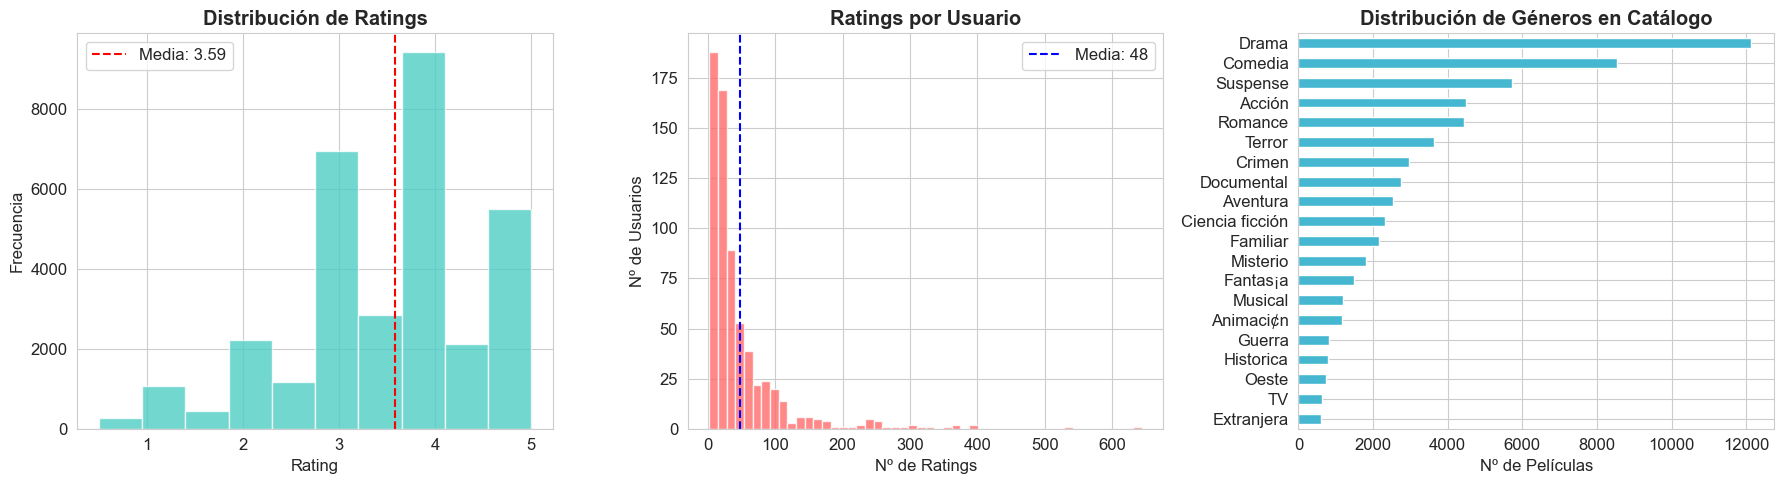

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de ratings
axes[0].hist(df_ratings_valid['rating'], bins=10, color='#4ECDC4', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de Ratings', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_ratings_valid['rating'].mean(), color='red', linestyle='--', label=f"Media: {df_ratings_valid['rating'].mean():.2f}")
axes[0].legend()

# Ratings por usuario
ratings_per_user = df_ratings_valid.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='#FF6B6B', edgecolor='white', alpha=0.8)
axes[1].set_title('Ratings por Usuario', fontweight='bold')
axes[1].set_xlabel('Nº de Ratings')
axes[1].set_ylabel('Nº de Usuarios')
axes[1].axvline(ratings_per_user.mean(), color='blue', linestyle='--', label=f"Media: {ratings_per_user.mean():.0f}")
axes[1].legend()

# Distribución de géneros en el catálogo
genre_counts = {}
for glist in pelicula_generos.values():
    for g in glist:
        name = id_dataset_to_genre_name.get(g, f'Desconocido({g})')
        genre_counts[name] = genre_counts.get(name, 0) + 1
genre_series = pd.Series(genre_counts).sort_values(ascending=True)
genre_series.plot(kind='barh', ax=axes[2], color='#45B7D1', edgecolor='white')
axes[2].set_title('Distribución de Géneros en Catálogo', fontweight='bold')
axes[2].set_xlabel('Nº de Películas')

plt.tight_layout()
plt.show()

---
## Fase 2: Construcción del Vector de Preferencias por Usuario

**Estrategia**: Distribución ponderada del rating entre los géneros de cada película.

Para cada película valorada por un usuario con rating $r$ y que tiene $k$ géneros:
- Cada género de esa película recibe una contribución de $\frac{r}{k}$

El ratio final de preferencia es la **media** de estas contribuciones para cada género:

$$\text{Preferencia}(u, g) = \frac{\sum_{i \in \text{peliculas\_con\_g}} \frac{r_i}{k_i}}{\text{count}(\text{peliculas\_con\_g})}$$

In [20]:
NUM_GENRES = len(df_generos)
users = sorted(df_ratings_valid['userId'].unique())
NUM_USERS = len(users)

print(f"🔨 Construyendo matriz de preferencias: {NUM_USERS} usuarios × {NUM_GENRES} géneros...")

# Inicializar matrices para acumular sumas y conteos
# user_genre_sum[u][g] = suma de contribuciones ponderadas
# user_genre_count[u][g] = número de películas que contribuyen
user_idx_map = {uid: idx for idx, uid in enumerate(users)}

user_genre_sum = np.zeros((NUM_USERS, NUM_GENRES))
user_genre_count = np.zeros((NUM_USERS, NUM_GENRES))

skipped = 0
processed = 0

for _, row in df_train.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    rating = row['rating']
    
    u_idx = user_idx_map[user_id]
    
    # Obtener géneros de esta película
    generos_pelicula = pelicula_generos.get(movie_id, [])
    
    if not generos_pelicula:
        skipped += 1
        continue
    
    k = len(generos_pelicula)  # número de géneros de esta película
    
    for g_dataset_id in generos_pelicula:
        g_idx = id_dataset_to_genre_idx.get(g_dataset_id)
        if g_idx is not None:
            user_genre_sum[u_idx, g_idx] += rating / k  # contribución ponderada
            user_genre_count[u_idx, g_idx] += 1
    
    processed += 1

print(f"   ✅ Procesados: {processed} ratings")
print(f"   ⚠️ Saltados (sin género): {skipped}")

🔨 Construyendo matriz de preferencias: 670 usuarios × 20 géneros...
   ✅ Procesados: 22411 ratings
   ⚠️ Saltados (sin género): 0


In [21]:
# Calcular la media: ratio = suma / count
# Donde count > 0, calculamos la media; donde count == 0, dejamos NaN
with np.errstate(divide='ignore', invalid='ignore'):
    user_genre_matrix = np.where(
        user_genre_count > 0,
        user_genre_sum / user_genre_count,
        np.nan
    )

# Crear DataFrame con la matriz
df_preferences = pd.DataFrame(
    user_genre_matrix,
    index=users,
    columns=genre_names
)
df_preferences.index.name = 'userId'

print(f"📊 Matriz de preferencias creada: {df_preferences.shape}")
print(f"\n--- Primeros 10 usuarios ---")
df_preferences.head(10).round(3)

📊 Matriz de preferencias creada: (670, 20)

--- Primeros 10 usuarios ---


,Aventura,Fantas¡a,Animaci¢n,Drama,Terror,Acción,Comedia,Historica,Oeste,Suspense,Crimen,Documental,Ciencia ficción,Misterio,Musical,Romance,Familiar,Guerra,Extranjera,TV
userId,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,1.500,NaN,NaN,2.000,0.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,NaN
2,1.438,1.250,1.667,1.694,2.333,1.667,1.323,NaN,NaN,1.450,1.458,1.000,1.271,0.972,1.000,1.667,1.208,NaN,NaN,NaN
3,0.800,0.800,NaN,1.857,2.000,0.875,4.250,NaN,NaN,1.417,1.125,NaN,0.800,1.125,NaN,NaN,0.800,NaN,NaN,0.800
4,1.278,1.327,0.833,2.089,1.579,1.285,2.561,1.625,NaN,1.249,1.513,NaN,1.305,1.514,2.000,1.545,1.000,1.417,0.833,NaN
5,0.958,1.408,NaN,1.967,1.939,1.275,1.755,1.333,2.125,1.544,1.758,2.083,1.294,1.528,2.000,1.483,1.167,NaN,2.000,NaN
6,0.833,0.667,NaN,2.088,NaN,1.000,0.760,NaN,4.000,1.000,1.000,2.000,1.333,NaN,NaN,1.625,0.375,NaN,NaN,0.375
7,1.333,1.222,NaN,2.078,2.111,1.278,0.750,2.500,NaN,1.889,1.333,NaN,1.500,1.542,0.875,1.194,1.333,NaN,NaN,NaN
8,1.000,NaN,1.125,2.285,2.250,1.132,2.031,NaN,1.167,1.382,1.708,NaN,1.229,1.167,2.000,1.542,1.000,NaN,NaN,NaN
9,1.375,1.417,NaN,2.167,1.333,1.317,1.717,NaN,NaN,1.467,1.556,4.000,1.417,1.278,2.000,1.333,NaN,NaN,NaN,NaN


In [22]:
# Estadísticas de cobertura (posiciones rellenas por usuario)
cobertura = df_preferences.notna().sum(axis=1)

print(f"\n📈 Cobertura de géneros por usuario:")
print(f"   Media de géneros cubiertos: {cobertura.mean():.1f} / {NUM_GENRES}")
print(f"   Mediana: {cobertura.median():.0f}")
print(f"   Mínimo: {cobertura.min()} | Máximo: {cobertura.max()}")
print(f"   Usuarios con cobertura completa (20/20): {(cobertura == NUM_GENRES).sum()}")
print(f"   Usuarios con ≥15 géneros: {(cobertura >= 15).sum()}")


📈 Cobertura de géneros por usuario:
   Media de géneros cubiertos: 13.3 / 20
   Mediana: 13
   Mínimo: 0 | Máximo: 20
   Usuarios con cobertura completa (20/20): 20
   Usuarios con ≥15 géneros: 277


---
## Fase 3: Normalización del Vector

Normalizamos los vectores de preferencia al rango **[0, 1]** usando Min-Max Scaling por usuario.  
Las posiciones sin información (`NaN`) se mantienen como `NaN`.

In [23]:
# Normalización a 0-100 y rellenado de NaN con 0
def normalize_to_100(row):
    # Rellenar NaNs con 0 (géneros no valorados)
    row = row.fillna(0)
    min_val = row.min()
    max_val = row.max()
    if max_val == min_val:
        if max_val == 0:
            return row
        else:
            return (row / max_val) * 100
    # Escalar a 0-100
    return (row - min_val) / (max_val - min_val) * 100

df_preferences_norm = df_preferences.apply(normalize_to_100, axis=1)

print("📊 Matriz normalizada [0, 100]:")
df_preferences_norm.head(10).round(2)


📊 Matriz normalizada [0, 100]:


,Aventura,Fantas¡a,Animaci¢n,Drama,Terror,Acción,Comedia,Historica,Oeste,Suspense,Crimen,Documental,Ciencia ficción,Misterio,Musical,Romance,Familiar,Guerra,Extranjera,TV
userId,,,,,,,,,,,,,,,,,,,,
1,0.00,0.00,0.00,75.00,0.00,0.00,100.00,25.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00
2,61.61,53.57,71.43,72.62,100.00,71.43,56.70,0.00,0.00,62.14,62.50,42.86,54.46,41.67,42.86,71.43,51.79,0.00,0.00,0.00
3,18.82,18.82,0.00,43.70,47.06,20.59,100.00,0.00,0.00,33.33,26.47,0.00,18.82,26.47,0.00,0.00,18.82,0.00,0.00,18.82
4,49.89,51.80,32.54,81.58,61.64,50.18,100.00,63.45,0.00,48.75,59.07,0.00,50.96,59.11,78.09,60.32,39.05,55.31,32.54,0.00
5,45.10,66.27,0.00,92.55,91.24,60.00,82.57,62.75,100.00,72.65,82.75,98.04,60.92,71.90,94.12,69.80,54.90,0.00,94.12,0.00
6,20.83,16.67,0.00,52.20,0.00,25.00,19.01,0.00,100.00,25.00,25.00,50.00,33.33,0.00,0.00,40.62,9.38,0.00,0.00,9.38
7,53.33,48.89,0.00,83.12,84.44,51.11,30.00,100.00,0.00,75.56,53.33,0.00,60.00,61.67,35.00,47.78,53.33,0.00,0.00,0.00
8,43.77,0.00,49.24,100.00,98.48,49.54,88.91,0.00,51.06,60.49,74.77,0.00,53.80,51.06,87.54,67.48,43.77,0.00,0.00,0.00
9,34.38,35.42,0.00,54.17,33.33,32.92,42.92,0.00,0.00,36.67,38.89,100.00,35.42,31.94,50.00,33.33,0.00,0.00,0.00,0.00


In [24]:
class PerfilUsuario:
    def __init__(self, user_id):
        self.user_id = user_id
        # Vector de 20 posiciones con valores entre 0 y 100
        self.preferencias = np.zeros(NUM_GENRES)
        
        # Histórico: dict de movieId -> rating (solo del set de entrenamiento)
        self.historico = {}
        
        # Información Interna (SR Colaborativo): vecinos y afinidad (0-100)
        self.vecinos = [] # Lista de tuplas (vecino_id, afinidad)
        
    def __repr__(self):
        return f"<PerfilUsuario {self.user_id} | {len(self.historico)} vistas | {len(self.vecinos)} vecinos>"

# Construimos los perfiles estructurados
perfiles = {}
for uid in users:
    perfil = PerfilUsuario(uid)
    perfil.preferencias = df_preferences_norm.loc[uid].values
    
    # Histórico del usuario extraído de ENTRENAMIENTO (df_train)
    user_train = df_train[df_train['userId'] == uid]
    perfil.historico = dict(zip(user_train['movieId'], user_train['rating']))
    perfiles[uid] = perfil

print(f"✅ Se han creado {len(perfiles)} perfiles de usuario.")
print("Ejemplo:", perfiles[users[0]])


✅ Se han creado 670 perfiles de usuario.
Ejemplo: <PerfilUsuario 1 | 4 vistas | 0 vecinos>


In [25]:
# También guardamos la versión sin normalizar para análisis
print("\n📊 Comparación de un usuario ejemplo (primero disponible):")
ejemplo_user = users[0]
comp = pd.DataFrame({
    'Preferencia_Raw': df_preferences.loc[ejemplo_user].round(3),
    'Preferencia_Norm': df_preferences_norm.loc[ejemplo_user].round(3),
    'Nº_Películas': user_genre_count[user_idx_map[ejemplo_user]]
})
comp = comp.dropna(subset=['Preferencia_Raw'])
print(f"\nUsuario {ejemplo_user}:")
comp


📊 Comparación de un usuario ejemplo (primero disponible):

Usuario 1:


,Preferencia_Raw,Preferencia_Norm,Nº_Películas
Drama,1.5,75.0,2.0
Comedia,2.0,100.0,2.0
Historica,0.5,25.0,1.0
Romance,2.0,100.0,1.0


---
## Fase 4: Análisis Exploratorio y Validación

### 4.1 Heatmap de la Matriz de Preferencias

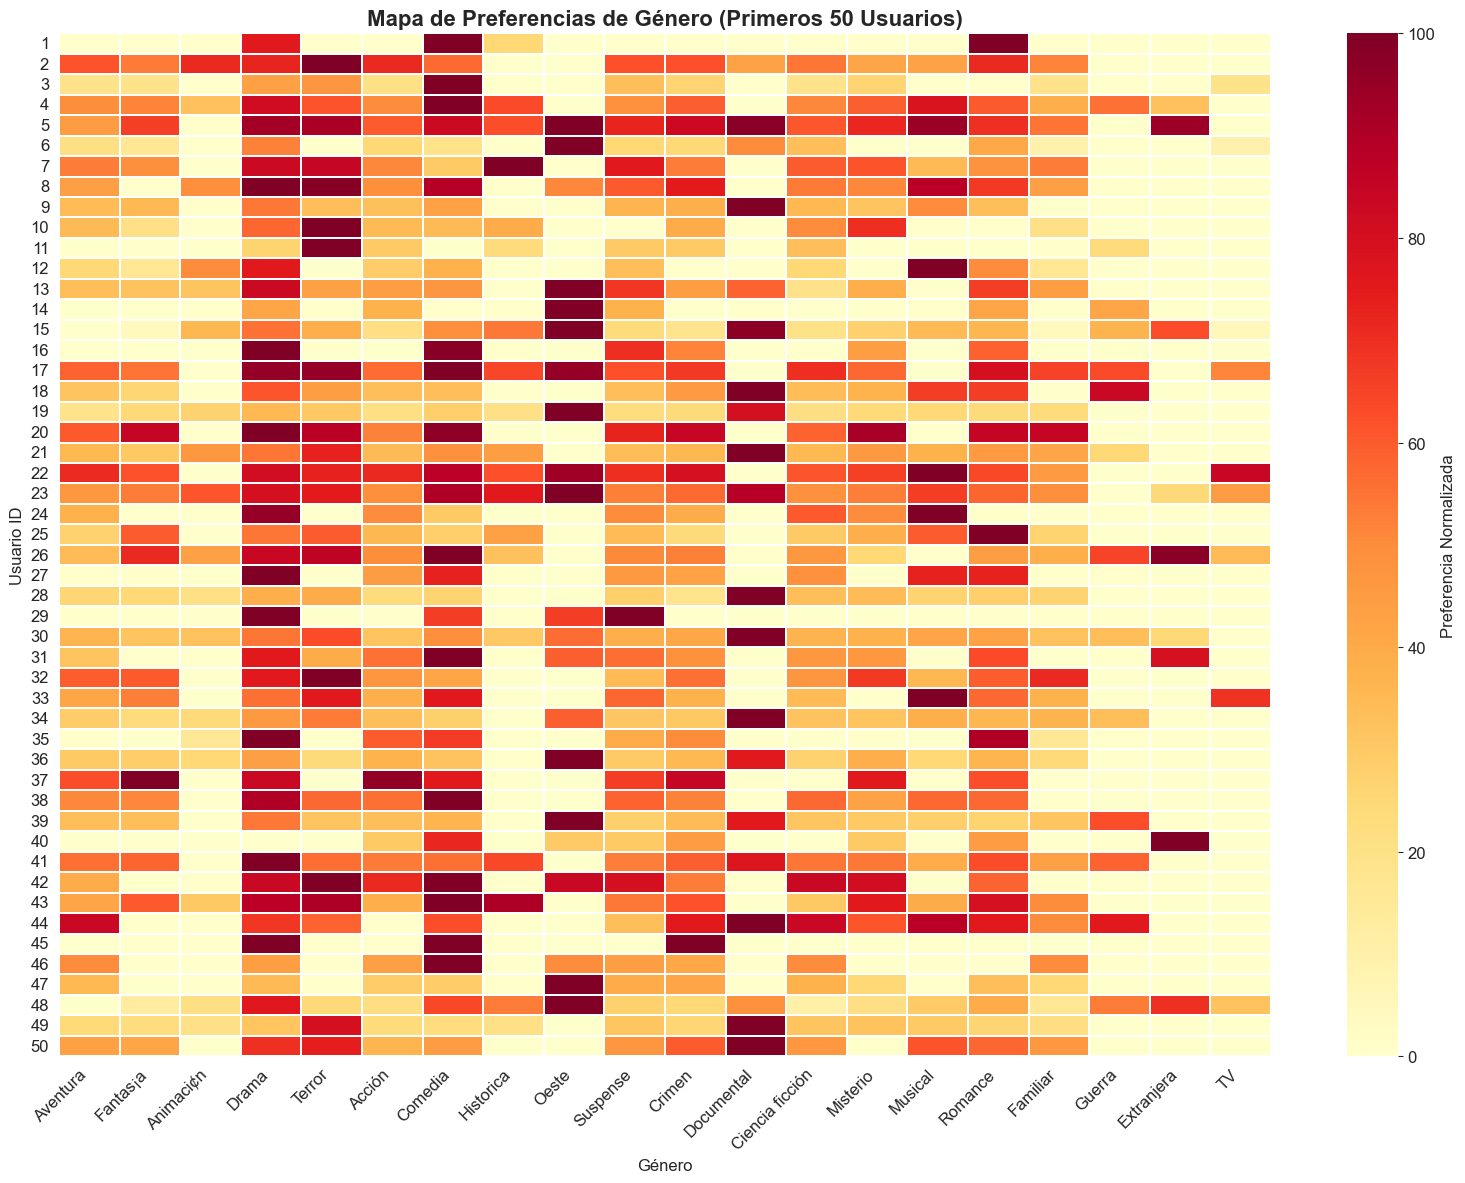

In [26]:
# Heatmap de una muestra de usuarios
sample_users = users[:50]  # Primeros 50 usuarios
sample_matrix = df_preferences_norm.loc[sample_users]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    sample_matrix,
    cmap='YlOrRd',
    annot=False,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Preferencia Normalizada'},
    linewidths=0.1,
    linecolor='white',
    ax=ax,
    mask=sample_matrix.isna()  # Mostrar NaN como vacío
)
ax.set_title('Mapa de Preferencias de Género (Primeros 50 Usuarios)', fontsize=16, fontweight='bold')
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Usuario ID', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2 Distribución de Cobertura

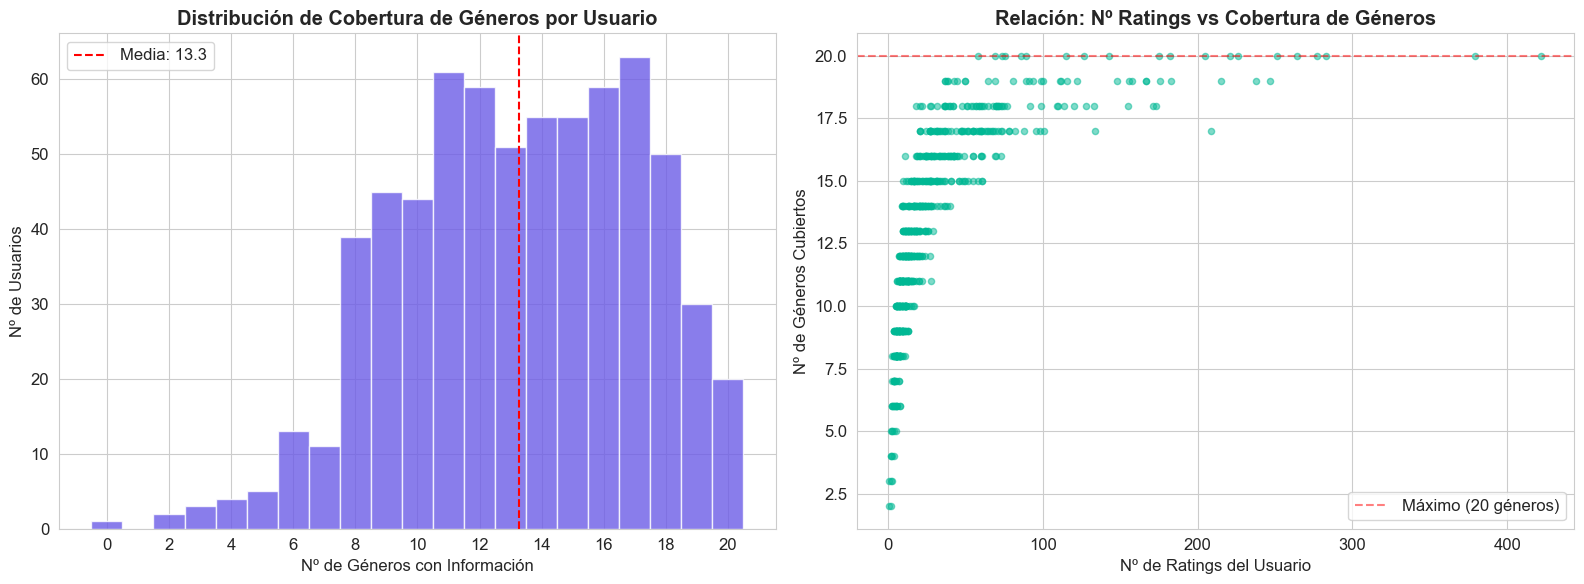

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de cobertura
axes[0].hist(cobertura, bins=range(0, NUM_GENRES + 2), color='#6C5CE7', edgecolor='white', alpha=0.8, align='left')
axes[0].set_title('Distribución de Cobertura de Géneros por Usuario', fontweight='bold')
axes[0].set_xlabel('Nº de Géneros con Información')
axes[0].set_ylabel('Nº de Usuarios')
axes[0].axvline(cobertura.mean(), color='red', linestyle='--', label=f"Media: {cobertura.mean():.1f}")
axes[0].legend()
axes[0].set_xticks(range(0, NUM_GENRES + 1, 2))

# Relación entre nº de ratings y cobertura
ratings_count = df_train.groupby('userId').size()
scatter_data = pd.DataFrame({'ratings': ratings_count, 'cobertura': cobertura})
axes[1].scatter(scatter_data['ratings'], scatter_data['cobertura'], alpha=0.5, s=20, color='#00B894')
axes[1].set_title('Relación: Nº Ratings vs Cobertura de Géneros', fontweight='bold')
axes[1].set_xlabel('Nº de Ratings del Usuario')
axes[1].set_ylabel('Nº de Géneros Cubiertos')
axes[1].axhline(NUM_GENRES, color='red', linestyle='--', alpha=0.5, label='Máximo (20 géneros)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.3 Preferencias Globales y Top Géneros

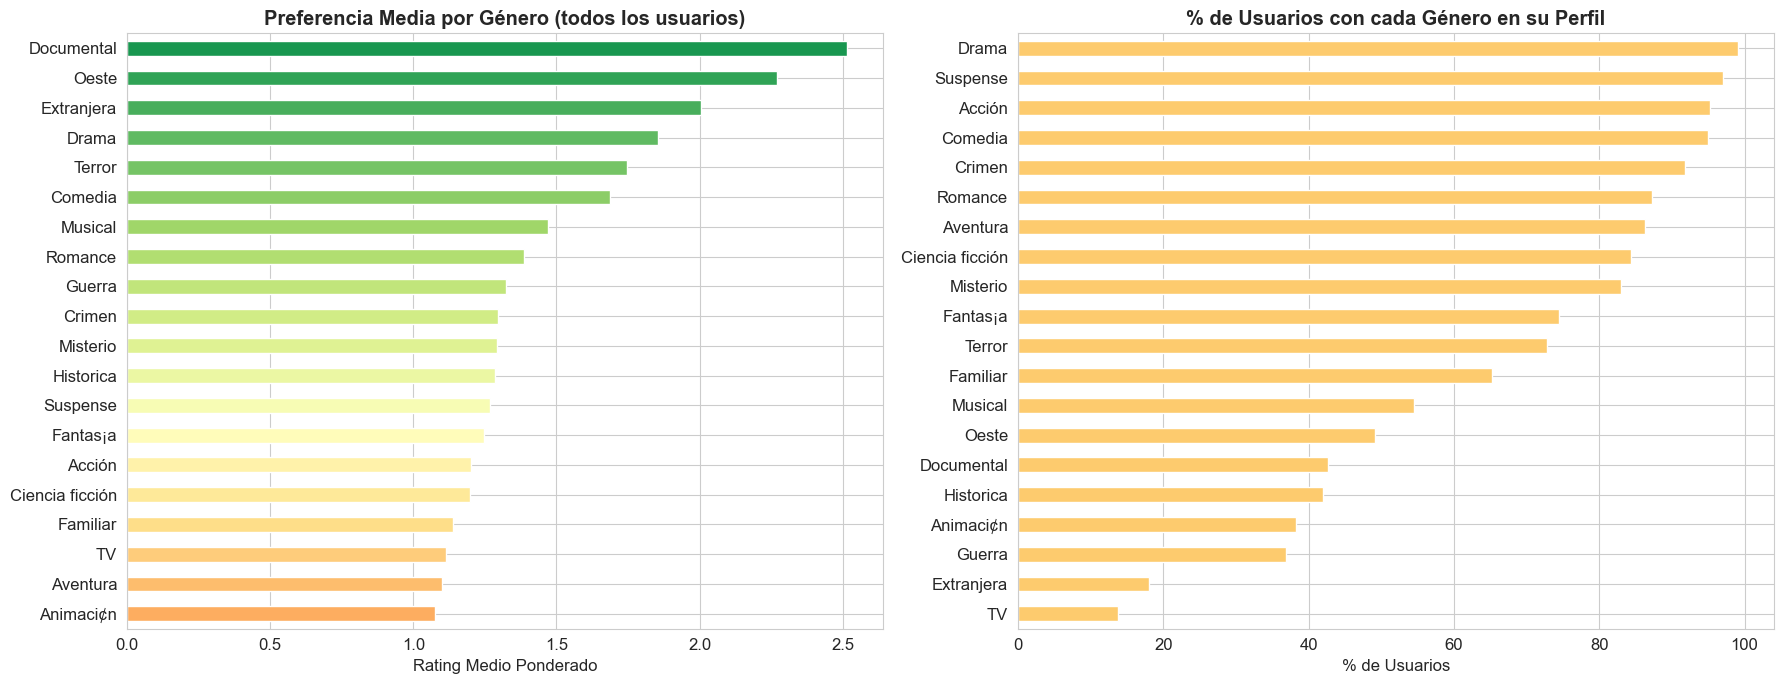

In [28]:
# Preferencia media global por género
global_pref = df_preferences.mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Preferencia media
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(global_pref)))
global_pref.plot(kind='barh', ax=axes[0], color=colors[::-1], edgecolor='white')
axes[0].set_title('Preferencia Media por Género (todos los usuarios)', fontweight='bold')
axes[0].set_xlabel('Rating Medio Ponderado')
axes[0].invert_yaxis()

# Porcentaje de usuarios que tienen cada género
genre_popularity = (df_preferences.notna().sum() / NUM_USERS * 100).sort_values(ascending=False)
genre_popularity.plot(kind='barh', ax=axes[1], color='#FDCB6E', edgecolor='white')
axes[1].set_title('% de Usuarios con cada Género en su Perfil', fontweight='bold')
axes[1].set_xlabel('% de Usuarios')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.4 Perfil de Usuarios Ejemplo

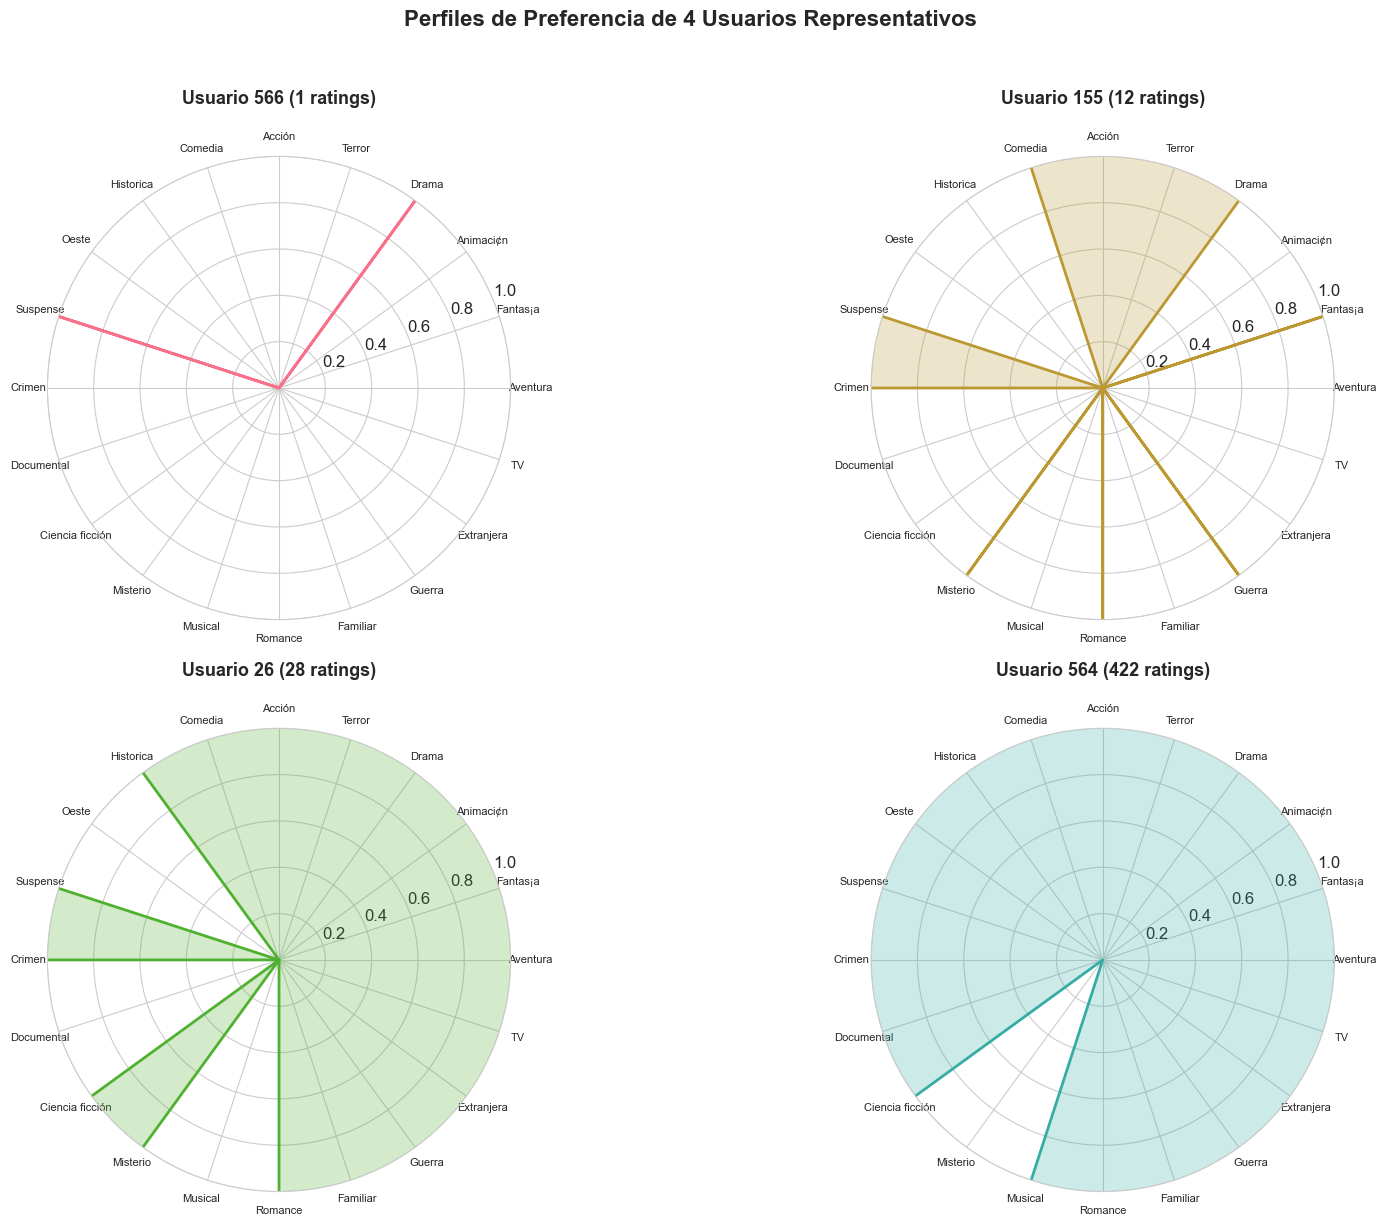

In [29]:
# Seleccionar 4 usuarios representativos
# Uno con pocos ratings, uno con muchos, y dos intermedios
user_rating_counts = df_train.groupby('userId').size().sort_values()
example_users = [
    user_rating_counts.index[0],         # Menos ratings
    user_rating_counts.index[len(user_rating_counts)//3],  # Tercil inferior
    user_rating_counts.index[2*len(user_rating_counts)//3],  # Tercil superior
    user_rating_counts.index[-1]          # Más ratings
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, uid in enumerate(example_users):
    ax = axes[idx]
    n_ratings = user_rating_counts[uid]
    
    values = df_preferences_norm.loc[uid].fillna(0).values
    categories = genre_names
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    values_plot = np.concatenate([values, [values[0]]])
    angles += angles[:1]
    
    ax.fill(angles, values_plot, alpha=0.25, color=f'C{idx}')
    ax.plot(angles, values_plot, linewidth=2, color=f'C{idx}')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_title(f'Usuario {uid} ({n_ratings} ratings)', fontweight='bold', size=13, pad=20)
    ax.set_ylim(0, 1)

plt.suptitle('Perfiles de Preferencia de 4 Usuarios Representativos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Correlación entre Géneros

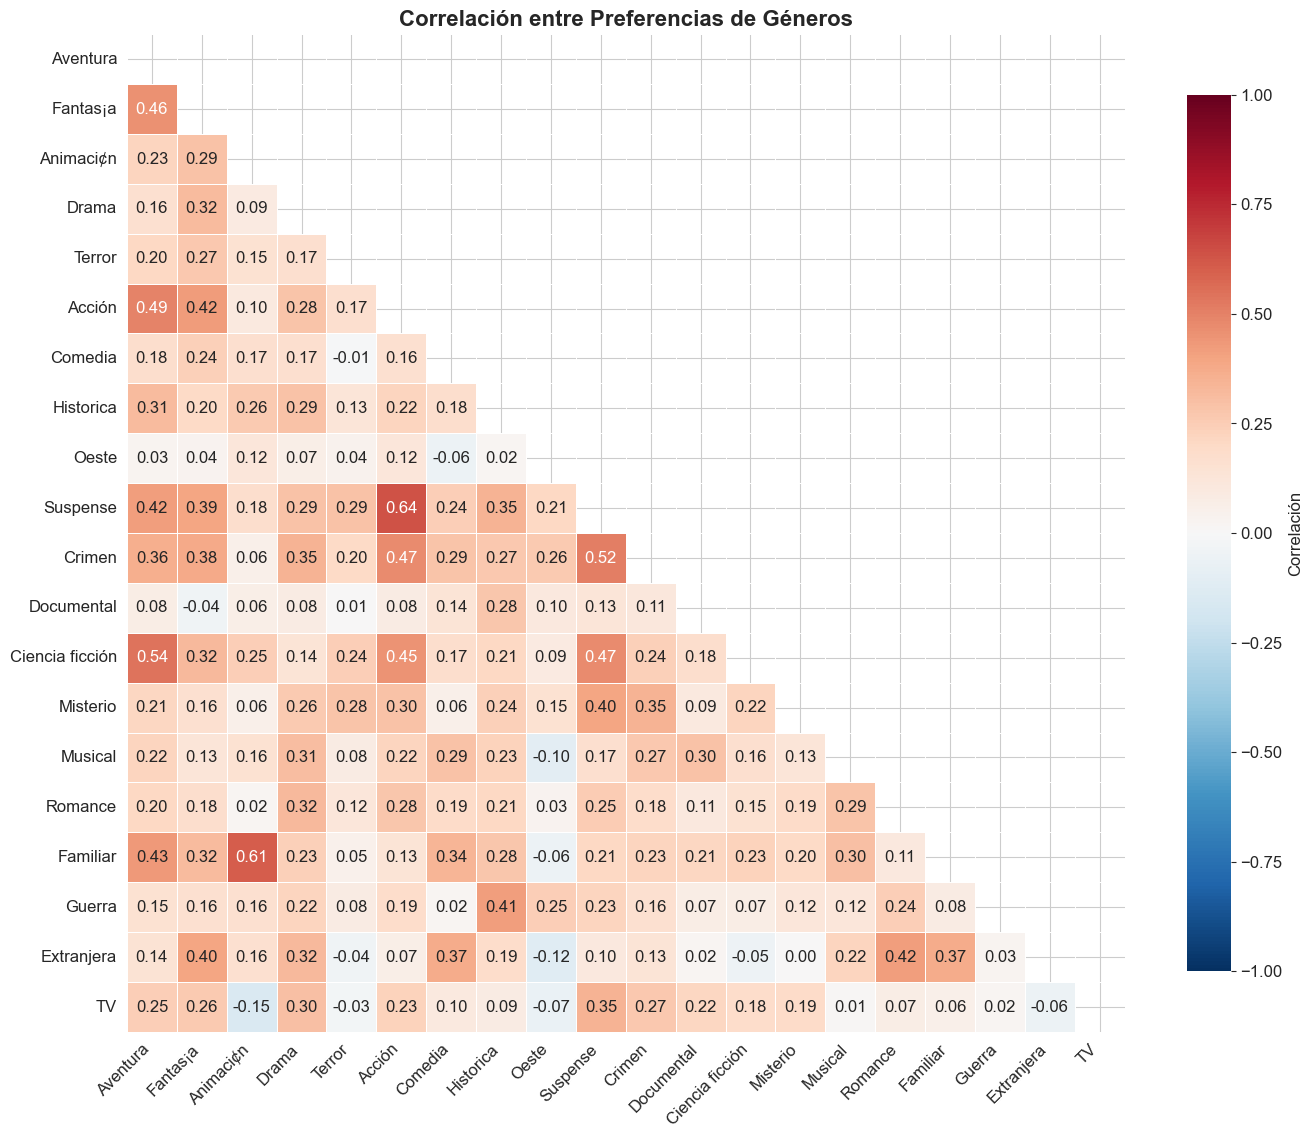

In [30]:
# Matriz de correlación entre las preferencias de los géneros
corr_matrix = df_preferences.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Correlación entre Preferencias de Géneros', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.6 Validación Manual

Verificamos el cálculo del vector para un usuario concreto trazando manualmente sus ratings.

In [31]:
# Validación manual para userId = 1
test_user = users[0]
print(f"🔍 Validación manual para Usuario {test_user}")
print("=" * 70)

user_ratings = df_train[df_train['userId'] == test_user]
print(f"\nPelículas valoradas: {len(user_ratings)}")

# Mostrar detalle de cada película y sus géneros
manual_sums = np.zeros(NUM_GENRES)
manual_counts = np.zeros(NUM_GENRES)

for _, row in user_ratings.iterrows():
    movie_id = row['movieId']
    rating = row['rating']
    generos = pelicula_generos.get(movie_id, [])
    
    if not generos:
        continue
    
    genre_names_this = [id_dataset_to_genre_name.get(g, '?') for g in generos]
    k = len(generos)
    
    # Buscar título
    titulo_row = df_peliculas[df_peliculas['id'] == movie_id]
    titulo = titulo_row['titulo'].values[0] if len(titulo_row) > 0 else '?'
    
    print(f"  📽️ {titulo} (id={movie_id}) | Rating: {rating} | Géneros ({k}): {genre_names_this}")
    
    for g_dataset_id in generos:
        g_idx = id_dataset_to_genre_idx.get(g_dataset_id)
        if g_idx is not None:
            manual_sums[g_idx] += rating / k
            manual_counts[g_idx] += 1

print("\n📊 Vector calculado manualmente vs. programáticamente:")
for g_idx in range(NUM_GENRES):
    if manual_counts[g_idx] > 0:
        manual_val = manual_sums[g_idx] / manual_counts[g_idx]
        prog_val = df_preferences.loc[test_user].iloc[g_idx]
        match = '✅' if abs(manual_val - prog_val) < 0.001 else '❌'
        print(f"  {match} {genre_names[g_idx]:20s}: Manual={manual_val:.3f} | Programa={prog_val:.3f} | Películas={int(manual_counts[g_idx])}")

🔍 Validación manual para Usuario 1

Películas valoradas: 4
  📽️ Rocky III (id=1371.0) | Rating: 2.5 | Géneros (1): ['Drama']
  📽️ Jay and Silent Bob Strike Back (id=2294.0) | Rating: 2.0 | Géneros (1): ['Comedia']
  📽️ American Pie (id=2105.0) | Rating: 4.0 | Géneros (2): ['Comedia', 'Romance']
  📽️ Greed (id=1405.0) | Rating: 1.0 | Géneros (2): ['Drama', 'Historica']

📊 Vector calculado manualmente vs. programáticamente:
  ✅ Drama               : Manual=1.500 | Programa=1.500 | Películas=2
  ✅ Comedia             : Manual=2.000 | Programa=2.000 | Películas=2
  ✅ Historica           : Manual=0.500 | Programa=0.500 | Películas=1
  ✅ Romance             : Manual=2.000 | Programa=2.000 | Películas=1


---
## Fase 5: Filtro de Recomendación Básico

Implementamos una función de recomendación que:
1. Toma las **n posiciones más altas** del vector del usuario
2. Busca películas no vistas que pertenezcan a esos géneros
3. Las ordena por su puntuación media en el dataset

In [32]:
def recomendar(user_id, n_recomendaciones=10):
    """
    Recomienda películas a un usuario calculando el ratio de interés 
    en base a sus preferencias inferidas en el perfil.
    """
    perfil = perfiles.get(user_id)
    if not perfil:
        print(f"⚠️ El usuario {user_id} no tiene un perfil/preferencias calculadas.")
        return pd.DataFrame()
        
    prefs = perfil.preferencias
    vistas = set(perfil.historico.keys())
    
    candidatas = []
    for movie_id, generos in pelicula_generos.items():
        if movie_id in vistas:
            continue
            
        if not generos:
            continue
            
        ratio_interes = 0
        k = 0
        for g_dataset_id in generos:
            g_idx = id_dataset_to_genre_idx.get(g_dataset_id)
            if g_idx is not None:
                ratio_interes += prefs[g_idx]
                k += 1
                
        if k > 0:
            ratio_interes /= k
            candidatas.append((movie_id, ratio_interes))
            
    if not candidatas:
        print("⚠️ No se encontraron candidatas.")
        return pd.DataFrame()
        
    # Ordenar por ratio de interés (de mayor a menor)
    candidatas.sort(key=lambda x: x[1], reverse=True)
    top_candidatas = candidatas[:n_recomendaciones]
    
    res = []
    for m_id, ratio in top_candidatas:
        titulo_row = df_peliculas[df_peliculas['id'] == m_id]
        titulo = titulo_row['titulo'].values[0] if len(titulo_row) > 0 else '?'
        res.append((m_id, titulo, ratio))
        
    resultado = pd.DataFrame(res, columns=['movieId', 'titulo', 'ratio_interes'])
    resultado.index += 1
    return resultado


In [33]:
# Ejemplo de recomendación
test_user_rec = users[3]  # Tomamos un usuario con bastantes ratings

recomendaciones = recomendar(test_user_rec, n_recomendaciones=15)

print(f"🎯 Recomendaciones para Usuario {test_user_rec}")
print(f"\n🎬 Top 15 Películas Recomendadas ordenadas por Ratio de interés:")
recomendaciones


🎯 Recomendaciones para Usuario 4

🎬 Top 15 Películas Recomendadas ordenadas por Ratio de interés:


,movieId,titulo,ratio_interes
1,496,Borat: Cultural Learnings of America for Make ...,100.0
2,583,Life of Brian,100.0
3,813,Airplane!,100.0
4,864,Cool Runnings,100.0
5,911,The Bank Dick,100.0
6,914,The Great Dictator,100.0
7,951,Kindergarten Cop,100.0
8,1281,Bean,100.0
9,1588,Bring It On,100.0
10,1609,There's Only One Jimmy Grimble,100.0


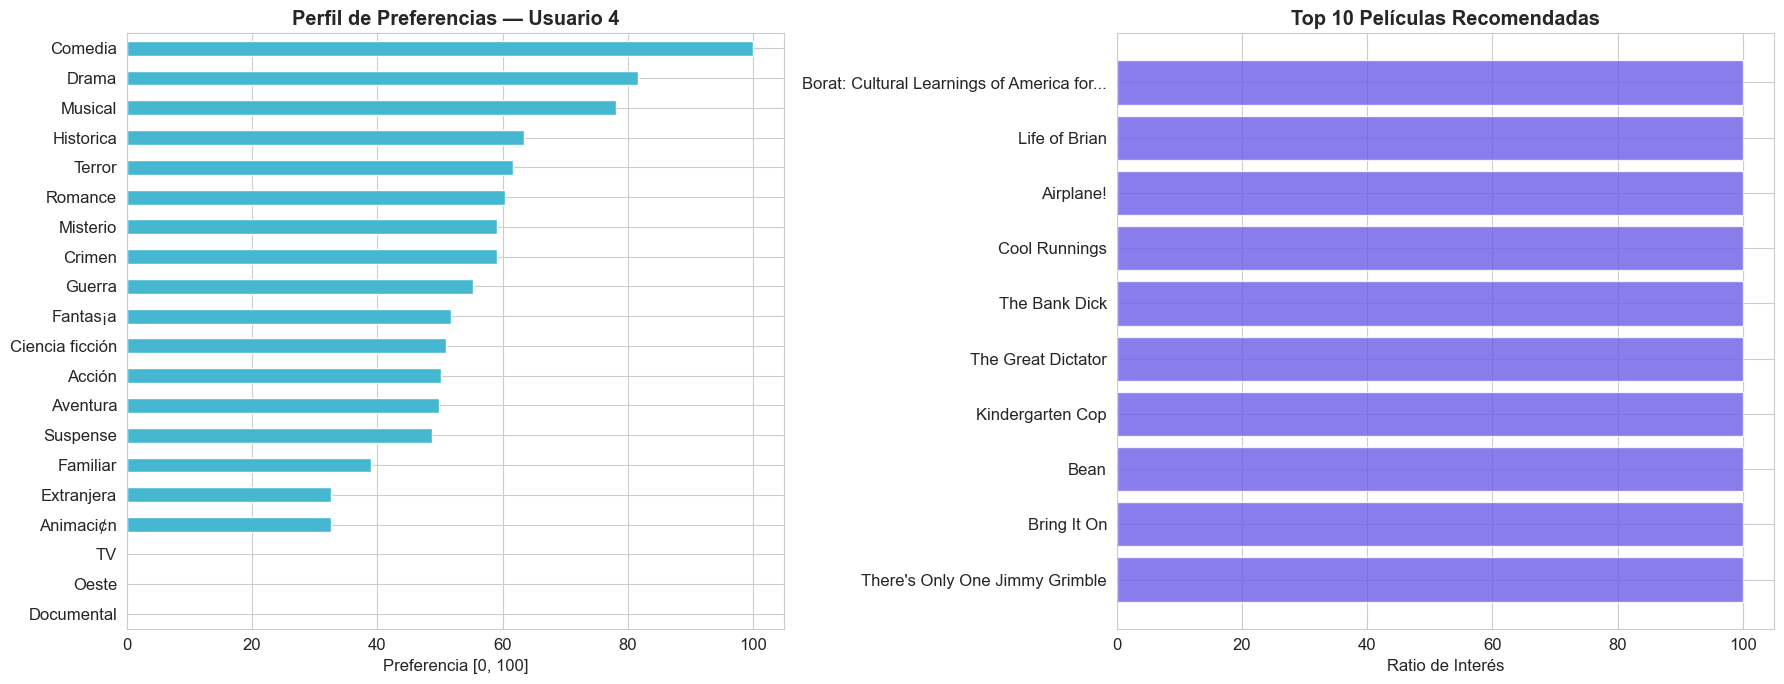

In [34]:
# Visualizar el perfil del usuario y sus recomendaciones
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Perfil del usuario
user_profile = df_preferences_norm.loc[test_user_rec].sort_values(ascending=True)
user_profile.plot(kind='barh', ax=axes[0], color='#45B7D1', edgecolor='white')
axes[0].set_title(f'Perfil de Preferencias — Usuario {test_user_rec}', fontweight='bold')
axes[0].set_xlabel('Preferencia [0, 100]')

# Scores de las recomendaciones
if len(recomendaciones) > 0:
    rec_display = recomendaciones.head(10)
    y_pos = range(len(rec_display))
    axes[1].barh(y_pos, rec_display['ratio_interes'], color='#6C5CE7', edgecolor='white', alpha=0.8)
    axes[1].set_yticks(y_pos)
    # Truncar títulos largos
    labels = [t[:40] + '...' if len(str(t)) > 40 else str(t) for t in rec_display['titulo']]
    axes[1].set_yticklabels(labels)
    axes[1].set_title('Top 10 Películas Recomendadas', fontweight='bold')
    axes[1].set_xlabel('Ratio de Interés')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


---
## Fase 6: Exportación de Resultados

In [35]:
# Crear directorio de resultados
results_dir = Path('resultados')
results_dir.mkdir(exist_ok=True)

# Exportar matriz de preferencias raw
df_preferences.to_csv(results_dir / 'user_genre_matrix_raw.csv', sep=';', decimal=',')
print(f"✅ Matriz raw guardada en: {results_dir / 'user_genre_matrix_raw.csv'}")

# Exportar matriz normalizada
df_preferences_norm.to_csv(results_dir / 'user_genre_matrix_normalized.csv', sep=';', decimal=',')
print(f"✅ Matriz normalizada guardada en: {results_dir / 'user_genre_matrix_normalized.csv'}")

# Exportar conteos (cuántas películas contribuyen a cada género por usuario)
df_counts = pd.DataFrame(
    user_genre_count,
    index=users,
    columns=genre_names
)
df_counts.index.name = 'userId'
df_counts.to_csv(results_dir / 'user_genre_counts.csv', sep=';')
print(f"✅ Conteos guardados en: {results_dir / 'user_genre_counts.csv'}")

✅ Matriz raw guardada en: resultados\user_genre_matrix_raw.csv
✅ Matriz normalizada guardada en: resultados\user_genre_matrix_normalized.csv
✅ Conteos guardados en: resultados\user_genre_counts.csv


---
## Resumen y Conclusiones

### Resultados clave

In [36]:
print("=" * 70)
print("📋 RESUMEN DEL TRABAJO 2: DATOS BASE")
print("=" * 70)
print(f"\n📦 Dataset:")
print(f"   • {len(df_peliculas)} películas en catálogo")
print(f"   • {NUM_GENRES} géneros")
print(f"   • {len(df_ratings)} ratings totales")
print(f"   • {len(df_ratings_valid)} ratings válidos (con info de género)")
print(f"   • {NUM_USERS} usuarios")

print(f"\n📊 Matriz de Preferencias:")
print(f"   • Dimensiones: {df_preferences.shape[0]} × {df_preferences.shape[1]}")
print(f"   • Método: Distribución ponderada del rating entre géneros")
print(f"   • Normalización: Min-Max [0, 1] por usuario")

print(f"\n📈 Cobertura:")
print(f"   • Media de géneros cubiertos/usuario: {cobertura.mean():.1f} / {NUM_GENRES}")
print(f"   • Usuarios con cobertura completa: {(cobertura == NUM_GENRES).sum()} ({100*(cobertura == NUM_GENRES).sum()/NUM_USERS:.1f}%)")
print(f"   • Usuarios con ≥15 géneros: {(cobertura >= 15).sum()} ({100*(cobertura >= 15).sum()/NUM_USERS:.1f}%)")

print(f"\n🏆 Top 5 géneros más populares:")
for name, pct in genre_popularity.head().items():
    print(f"   • {name}: {pct:.1f}% de usuarios")

print(f"\n💾 Archivos exportados en: {results_dir.resolve()}")
print("=" * 70)

📋 RESUMEN DEL TRABAJO 2: DATOS BASE

📦 Dataset:
   • 27840 películas en catálogo
   • 20 géneros
   • 100004 ratings totales
   • 32016 ratings válidos (con info de género)
   • 670 usuarios

📊 Matriz de Preferencias:
   • Dimensiones: 670 × 20
   • Método: Distribución ponderada del rating entre géneros
   • Normalización: Min-Max [0, 1] por usuario

📈 Cobertura:
   • Media de géneros cubiertos/usuario: 13.3 / 20
   • Usuarios con cobertura completa: 20 (3.0%)
   • Usuarios con ≥15 géneros: 277 (41.3%)

🏆 Top 5 géneros más populares:
   • Drama: 99.1% de usuarios
   • Suspense: 97.0% de usuarios
   • Acción: 95.2% de usuarios
   • Comedia: 94.9% de usuarios
   • Crimen: 91.8% de usuarios

💾 Archivos exportados en: C:\Users\jlina\Desktop\Master\SR\Trabajo\SistemasRecomendadores-MIARFID\Trabajo\resultados
